In [1]:
# Import required libraries for dataset handling and data manipulation
from datasets import load_dataset_builder , load_dataset
import pandas as pd
import matplotlib.pyplot as plt


# Load the dataset builder to inspect metadata without downloading the full dataset
ds_builder_artificial = load_dataset_builder("qiaojin/PubMedQA", 'pqa_artificial')

In [2]:
ds_builder_artificial.info.features

{'pubid': Value('int32'),
 'question': Value('string'),
 'context': {'contexts': List(Value('string')),
  'labels': List(Value('string')),
  'meshes': List(Value('string'))},
 'long_answer': Value('string'),
 'final_decision': Value('string')}

In [3]:
ds_artificial = load_dataset("qiaojin/PubMedQA", 'pqa_artificial')

In [4]:
ds_artificial['train'][0]

{'pubid': 25429730,
 'question': 'Are group 2 innate lymphoid cells ( ILC2s ) increased in chronic rhinosinusitis with nasal polyps or eosinophilia?',
 'context': {'contexts': ['Chronic rhinosinusitis (CRS) is a heterogeneous disease with an uncertain pathogenesis. Group 2 innate lymphoid cells (ILC2s) represent a recently discovered cell population which has been implicated in driving Th2 inflammation in CRS; however, their relationship with clinical disease characteristics has yet to be investigated.',
   'The aim of this study was to identify ILC2s in sinus mucosa in patients with CRS and controls and compare ILC2s across characteristics of disease.',
   'A cross-sectional study of patients with CRS undergoing endoscopic sinus surgery was conducted. Sinus mucosal biopsies were obtained during surgery and control tissue from patients undergoing pituitary tumour resection through transphenoidal approach. ILC2s were identified as CD45(+) Lin(-) CD127(+) CD4(-) CD8(-) CRTH2(CD294)(+) CD

In [5]:
df_train_artificial = ds_artificial['train'].to_pandas()

In [6]:
df_train_artificial.head(10)

,pubid,question,context,long_answer,final_decision
0,25429730,Are group 2 innate lymphoid cells ( ILC2s ) in...,{'contexts': ['Chronic rhinosinusitis (CRS) is...,"As ILC2s are elevated in patients with CRSwNP,...",yes
1,25433161,Does vagus nerve contribute to the development...,{'contexts': ['Phosphatidylethanolamine N-meth...,Neuronal signals via the hepatic vagus nerve c...,yes
2,25445714,Does psammaplin A induce Sirtuin 1-dependent a...,{'contexts': ['Psammaplin A (PsA) is a natural...,PsA significantly inhibited MCF-7/adr cells pr...,yes
3,25431941,Is methylation of the FGFR2 gene associated wi...,{'contexts': ['This study examined links betwe...,We identified a novel biologically plausible c...,yes
4,25432519,Do tumor-infiltrating immune cell profiles and...,{'contexts': ['Tumor microenvironment immunity...,Breast cancer immune cell subpopulation profil...,yes
5,25440440,Is hidradenitis suppurativa a systemic disease...,{'contexts': ['Hidradenitis suppurativa (HS) i...,Control subjects were not validated for absenc...,yes
6,25444977,Does reference range for serum and salivary te...,{'contexts': ['The interassay variability foun...,"In men from the Mediterranean region, values o...",yes
7,25429648,Are secretory phospholipases A2 secreted from ...,{'contexts': ['Secretory phospholipases A2 (sP...,sPLA2 are secreted from ciliated cells and app...,yes
8,25424148,Is admission hyperglycemia associated with fai...,{'contexts': ['Hyperglycemia on admission is a...,"In patients with STEMI who undergo FT, admissi...",yes
9,25447560,Do systematic Reviews Published in Emergency M...,{'contexts': ['Publication bias compromises th...,Systematic reviews published in emergency medi...,no


In [7]:
ds_builder_labeled = load_dataset_builder("qiaojin/PubMedQA", 'pqa_labeled')

In [8]:
ds_builder_labeled.info.features

{'pubid': Value('int32'),
 'question': Value('string'),
 'context': {'contexts': List(Value('string')),
  'labels': List(Value('string')),
  'meshes': List(Value('string')),
  'reasoning_required_pred': List(Value('string')),
  'reasoning_free_pred': List(Value('string'))},
 'long_answer': Value('string'),
 'final_decision': Value('string')}

In [9]:
ds_labeled = load_dataset("qiaojin/PubMedQA", 'pqa_labeled')

In [10]:
ds_labeled['train'][0]

{'pubid': 21645374,
 'question': 'Do mitochondria play a role in remodelling lace plant leaves during programmed cell death?',
 'context': {'contexts': ['Programmed cell death (PCD) is the regulated death of cells within an organism. The lace plant (Aponogeton madagascariensis) produces perforations in its leaves through PCD. The leaves of the plant consist of a latticework of longitudinal and transverse veins enclosing areoles. PCD occurs in the cells at the center of these areoles and progresses outwards, stopping approximately five cells from the vasculature. The role of mitochondria during PCD has been recognized in animals; however, it has been less studied during PCD in plants.',
   'The following paper elucidates the role of mitochondrial dynamics during developmentally regulated PCD in vivo in A. madagascariensis. A single areole within a window stage leaf (PCD is occurring) was divided into three areas based on the progression of PCD; cells that will not undergo PCD (NPCD), ce

In [11]:
df_train_labeled = ds_labeled['train'].to_pandas()

In [12]:
df_train_labeled.head(10)

,pubid,question,context,long_answer,final_decision
0,21645374,Do mitochondria play a role in remodelling lac...,{'contexts': ['Programmed cell death (PCD) is ...,Results depicted mitochondrial dynamics in viv...,yes
1,16418930,Landolt C and snellen e acuity: differences in...,{'contexts': ['Assessment of visual acuity dep...,"Using the charts described, there was only a s...",no
2,9488747,"Syncope during bathing in infants, a pediatric...",{'contexts': ['Apparent life-threatening event...,"""Aquagenic maladies"" could be a pediatric form...",yes
3,17208539,Are the long-term results of the transanal pul...,{'contexts': ['The transanal endorectal pull-t...,Our long-term study showed significantly bette...,no
4,10808977,Can tailored interventions increase mammograph...,{'contexts': ['Telephone counseling and tailor...,The effects of the intervention were most pron...,yes
5,23831910,Double balloon enteroscopy: is it efficacious ...,{'contexts': ['From March 2007 to January 2011...,DBE appears to be equally safe and effective w...,yes
6,26037986,30-Day and 1-year mortality in emergency gener...,{'contexts': ['Emergency surgery is associated...,Emergency laparotomy carries a high rate of mo...,maybe
7,26852225,Is adjustment for reporting heterogeneity nece...,{'contexts': ['Anchoring vignettes are brief t...,Sleep disorders are common in the general adul...,no
8,17113061,Do mutations causing low HDL-C promote increas...,{'contexts': ['Although observational data sup...,Genetic variants identified in the present stu...,no
9,10966337,A short stay or 23-hour ward in a general and ...,{'contexts': ['We evaluated the usefulness of ...,This data demonstrates the robust nature of th...,yes


In [13]:
ds_builder_unlabeled = load_dataset_builder("qiaojin/PubMedQA", 'pqa_unlabeled')

In [14]:
ds_builder_unlabeled.info.features

{'pubid': Value('int32'),
 'question': Value('string'),
 'context': {'contexts': List(Value('string')),
  'labels': List(Value('string')),
  'meshes': List(Value('string'))},
 'long_answer': Value('string')}

In [15]:
ds_unlabeled = load_dataset("qiaojin/PubMedQA", 'pqa_unlabeled')

In [16]:
ds_unlabeled['train'][0]

{'pubid': 14499029,
 'question': 'Is naturopathy as effective as conventional therapy for treatment of menopausal symptoms?',
 'context': {'contexts': ['Although the use of alternative medicine in the United States is increasing, no published studies have documented the effectiveness of naturopathy for treatment of menopausal symptoms compared to women receiving conventional therapy in the clinical setting.',
   'To compare naturopathic therapy with conventional medical therapy for treatment of selected menopausal symptoms.',
   'A retrospective cohort study, using abstracted data from medical charts.',
   'One natural medicine and six conventional medical clinics at Community Health Centers of King County, Washington, from November 1, 1996, through July 31, 1998.',
   'Women aged 40 years of age or more with a diagnosis of menopausal symptoms documented by a naturopathic or conventional physician.',
   'Improvement in selected menopausal symptoms.',
   'In univariate analyses, patient

In [17]:
df_train_unlabeled = ds_unlabeled['train'].to_pandas()

In [18]:
df_train_unlabeled.head(10)

,pubid,question,context,long_answer
0,14499029,Is naturopathy as effective as conventional th...,{'contexts': ['Although the use of alternative...,Naturopathy appears to be an effective alterna...
1,14499049,Can randomised trials rely on existing electro...,"{'contexts': ['To estimate the feasibility, ut...",Routine data have the potential to support hea...
2,14499672,Is laparoscopic radical prostatectomy better t...,{'contexts': ['To compare morbidity in two gro...,The results of our non-randomized study show t...
3,14499773,Does bacterial gastroenteritis predispose peop...,{'contexts': ['Irritable bowel syndrome (IBS) ...,Symptoms consistent with IBS and functional di...
4,14499777,Is early colonoscopy after admission for acute...,{'contexts': ['Urgent colonoscopy has been pro...,No significant association is apparent between...
5,14500299,Does the use of a specialised paediatric retri...,{'contexts': ['To compare the proportion of ai...,Referring hospital staff are performing a grea...
6,14500315,Management of thoracic empyema in childhood: d...,{'contexts': ['To determine the clinical cours...,Results suggest that decortication is not nece...
7,14501446,Does repeated hyperbaric exposure to 4 atmosph...,{'contexts': ['Direct pressure applied on the ...,Pressure applied directly on the inner ear dur...
8,14501647,Lower urinary tract reconstruction for duplica...,{'contexts': ['Current practice in reconstruct...,Lower urinary tract reconstruction for duplica...
9,14501656,Is common sheath extravesical reimplantation a...,{'contexts': ['We evaluate the outcome vesicou...,Common sheath extravesical reimplantation is h...


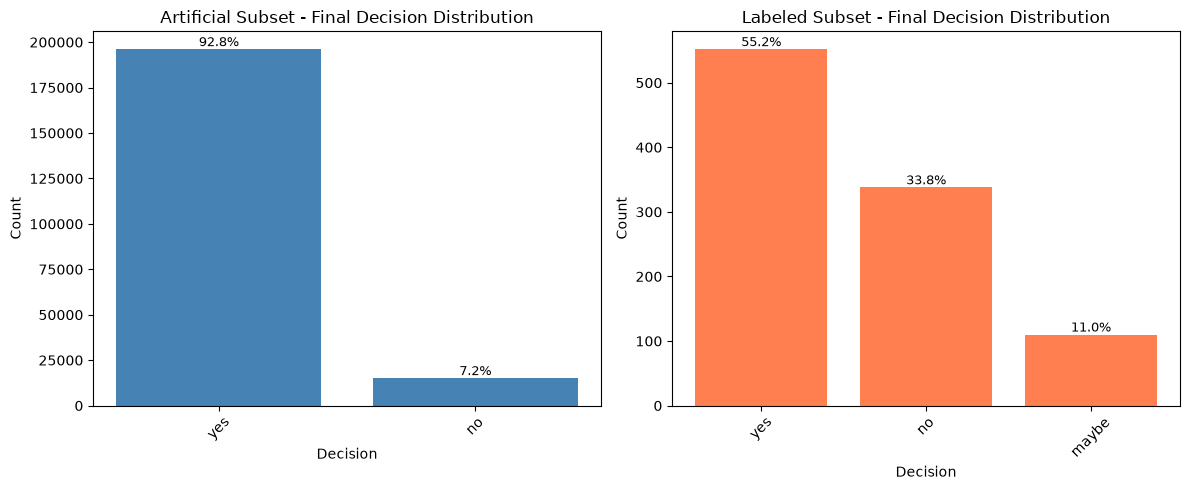

Note: The unlabeled subset contains no 'final_decision' column, only questions and contexts.


In [19]:
# Create a comparison visualization of final_decision distribution for labeled and artificial subsets
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

subset_specs = [
    (df_train_artificial, 'Artificial Subset - Final Decision Distribution', 'steelblue'),
    (df_train_labeled, 'Labeled Subset - Final Decision Distribution', 'coral')
]

for ax, (df, title, color) in zip(axes, subset_specs):
    vc = df['final_decision'].value_counts()
    total = vc.sum()

    bars = ax.bar(vc.index.astype(str), vc.values, color=color)
    ax.set_title(title)
    ax.set_xlabel('Decision')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)

    for bar, count in zip(bars, vc.values):
        pct = (count / total) * 100
        ax.annotate(
            f'{pct:.1f}%',
            (bar.get_x() + bar.get_width() / 2, bar.get_height()),
            ha='center',
            va='bottom',
            fontsize=9
        )

plt.tight_layout()
plt.show()

print("Note: The unlabeled subset contains no 'final_decision' column, only questions and contexts.")